# Exploratory Data Analysis

In [2]:
# load necessary libraries
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

# load the fact table
disaster = pd.read_csv("disasters_fact_table.csv", parse_dates=["declarationDate", "incidentBeginDate", "incidentEndDate"])

# preview the data

disaster.info()
disaster.head()

<class 'pandas.DataFrame'>
RangeIndex: 32042 entries, 0 to 32041
Data columns (total 36 columns):
 #   Column                            Non-Null Count  Dtype              
---  ------                            --------------  -----              
 0   disasterNumber                    32042 non-null  int64              
 1   state                             32042 non-null  str                
 2   incidentType                      32042 non-null  str                
 3   declarationDate                   32042 non-null  datetime64[us, UTC]
 4   incidentBeginDate                 32042 non-null  datetime64[us, UTC]
 5   incidentEndDate                   31842 non-null  datetime64[us, UTC]
 6   declarationType                   32042 non-null  str                
 7   declaration_year                  32042 non-null  int64              
 8   declaration_month                 32042 non-null  int64              
 9   declaration_quarter               32042 non-null  int64              
 1

,disasterNumber,state,incidentType,declarationDate,incidentBeginDate,incidentEndDate,declarationType,declaration_year,declaration_month,declaration_quarter,incident_duration_days,declaration_lag_days,incident_open_flag,state_disaster_frequency,totalAmountIhpApproved,totalAmountHaApproved,totalAmountOnaApproved,totalObligatedAmountPa,totalObligatedAmountHmgp,target_pa_cost,target_total_recovery_cost,log_target_pa_cost,log_target_total_cost,pa_project_count,pa_total_obligated_sum,pa_total_obligated_mean,pa_total_obligated_median,pa_total_obligated_max,large,small,large_project_ratio,totalAmountIhpApproved_missing,totalAmountHaApproved_missing,totalAmountOnaApproved_missing,totalObligatedAmountPa_missing,totalObligatedAmountHmgp_missing
0,5529,OR,Fire,2024-08-09 00:00:00+00:00,2024-08-08 00:00:00+00:00,NaT,FM,2024,8,3,NaN,1,1,294,0.0,0.0,0.0,0.00,0.00,0.00,0.00,0.000000,0.000000,0.0,0.00,0.000000,0.000,0.00,0.0,0.0,0.000000,1,1,1,1,0
1,5528,OR,Fire,2024-08-06 00:00:00+00:00,2024-08-04 00:00:00+00:00,NaT,FM,2024,8,3,NaN,2,1,294,0.0,0.0,0.0,0.00,0.00,0.00,0.00,0.000000,0.000000,0.0,0.00,0.000000,0.000,0.00,0.0,0.0,0.000000,1,1,1,1,0
2,5527,OR,Fire,2024-08-02 00:00:00+00:00,2024-08-02 00:00:00+00:00,NaT,FM,2024,8,3,NaN,0,1,294,0.0,0.0,0.0,0.00,0.00,0.00,0.00,0.000000,0.000000,0.0,0.00,0.000000,0.000,0.00,0.0,0.0,0.000000,1,1,1,1,0
3,4312,CA,Severe Storm,2017-05-02 00:00:00+00:00,2017-02-08 00:00:00+00:00,2017-02-11 00:00:00+00:00,DR,2017,5,2,3.0,83,0,739,0.0,0.0,0.0,269934.77,1650.00,269934.77,271584.77,12.505939,12.512033,2.0,269934.77,134967.385000,134967.385,233307.18,1.0,1.0,0.500000,1,1,1,0,0
4,4251,AL,Severe Storm,2016-01-21 00:00:00+00:00,2015-12-23 00:00:00+00:00,2015-12-31 00:00:00+00:00,DR,2016,1,1,8.0,29,0,743,0.0,0.0,0.0,36201886.24,5530482.83,36201886.24,41732369.07,17.404622,17.546788,693.0,36201886.01,52239.373752,26674.610,1739135.15,51.0,642.0,0.073593,1,1,1,0,0


In [ ]:
# basic stats and value counts
print(disaster.shape)
print("\n")
print(disaster["declaration_year"].min(), disaster["declaration_year"].max())
print("\n")
print(disaster["incidentType"].value_counts())

(32042, 36)


2010 2026


incidentType
Severe Storm           7888
Biological             7856
Hurricane              6267
Flood                  3528
Severe Ice Storm       1377
Fire                   1374
Winter Storm           1331
Tropical Storm         1059
Snowstorm               604
Tornado                 300
Coastal Storm           184
Earthquake              137
Mud/Landslide            41
Typhoon                  28
Other                    22
Dam/Levee Break          10
Chemical                  9
Tsunami                   9
Tropical Depression       7
Terrorist                 4
Straight-Line Winds       3
Volcanic Eruption         2
Freezing                  1
Toxic Substances          1
Name: count, dtype: int64


Too many incident categories for disasters

In [ ]:
# group incident types into broader categories
def group_incident(x):
    if x in ["Severe Storm", "Hurricane", "Flood", "Coastal Storm", "Tropical Storm"]:
        return "Storm"
    elif x in ["Fire"]:
        return "Fire"
    elif x in ["Biological"]:
        return "Biological"
    elif x in ["Snowstorm", "Winter Storm", "Severe Ice Storm", "Freezing"]:
        return "Winter"
    elif x in ["Tornado"]:
        return "Tornado"
    elif x in ["Tsunami"]:
        return "Tsunami"
    elif x in ["Earthquake", "Mud/Landslide"]:
        return "Earthquake"
    elif x in ["Chemical", "Toxic Substances"]:
        return "Chemical"
    else:
        return "Other"

disaster["incident_group"] = disaster["incidentType"].apply(group_incident)

In [5]:
disaster["incident_group"].value_counts()

incident_group
Storm         18926
Biological     7856
Winter         3313
Fire           1374
Tornado         300
Earthquake      178
Other            76
Chemical         10
Tsunami           9
Name: count, dtype: int64

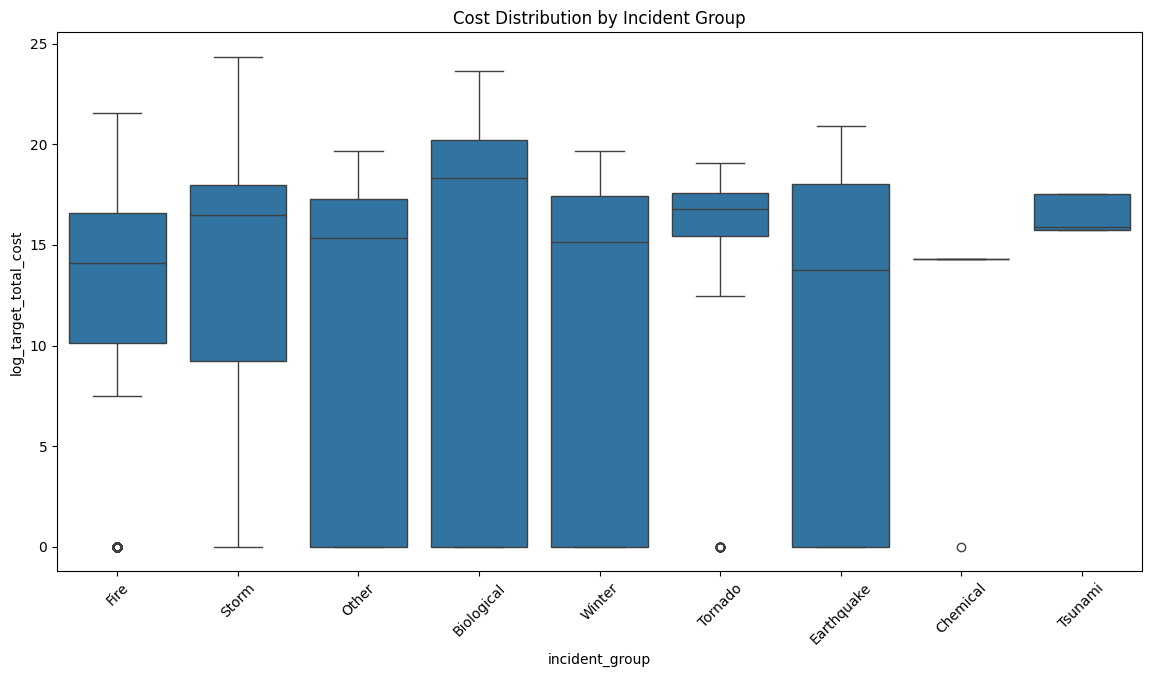

In [ ]:
# Visualize cost distribution by incident group
plt.figure(figsize=(14, 7))

sns.boxplot(
    data=disaster,
    x="incident_group",
    y="log_target_total_cost"
)

plt.xticks(rotation=45)
plt.title("Cost Distribution by Incident Group")
plt.show()

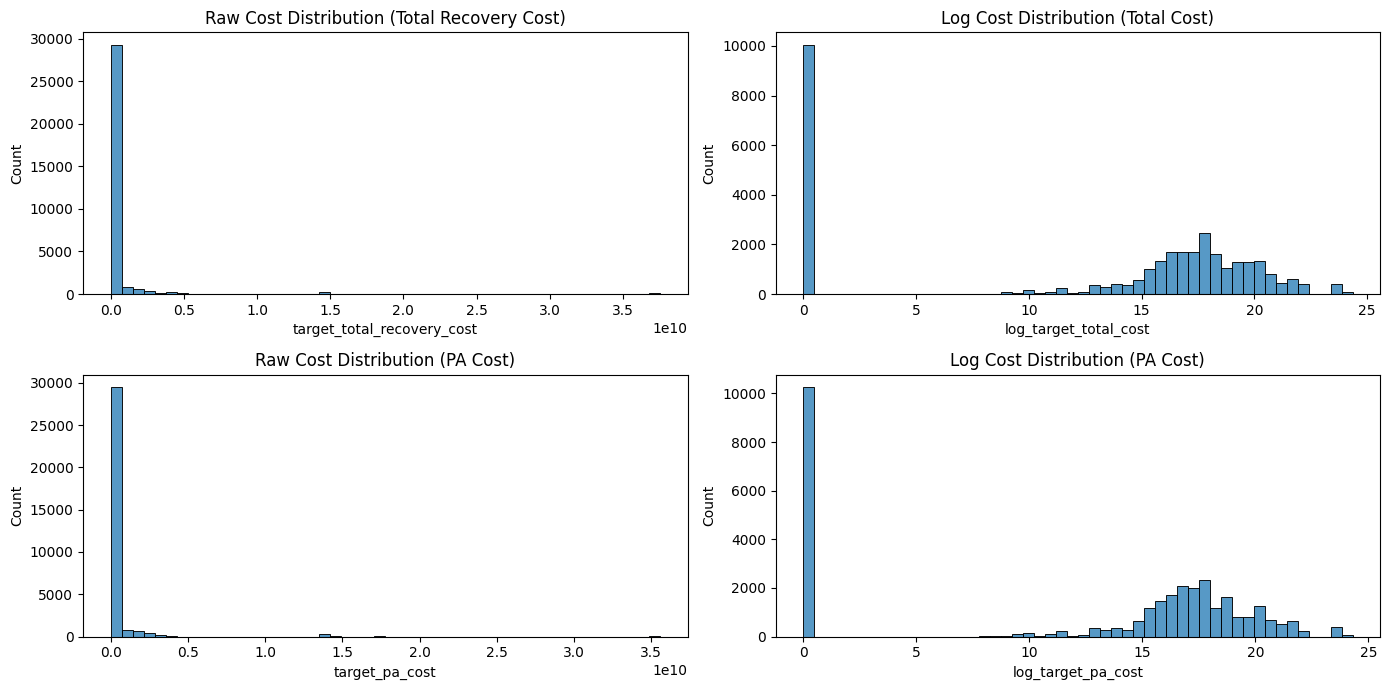

In [ ]:
# check if issues with skenewness are resolved by log transformation
fig, axes = plt.subplots(2, 2, figsize=(14, 7))

sns.histplot(disaster["target_total_recovery_cost"], bins=50, ax=axes[0, 0])
axes[0, 0].set_title("Raw Cost Distribution (Total Recovery Cost)")

sns.histplot(disaster["log_target_total_cost"], bins=50, ax=axes[0, 1])
axes[0, 1].set_title("Log Cost Distribution (Total Cost)")

sns.histplot(disaster["target_pa_cost"], bins=50, ax=axes[1, 0])
axes[1, 0].set_title("Raw Cost Distribution (PA Cost)")

sns.histplot(disaster["log_target_pa_cost"], bins=50, ax=axes[1, 1])
axes[1, 1].set_title("Log Cost Distribution (PA Cost)")


plt.tight_layout()
plt.show()

In [16]:
disaster["state"].value_counts()

state
TX    2049
KY    1716
GA    1547
LA    1495
FL    1359
NC    1315
OK    1234
PR    1176
MO    1129
VA    1100
MS    1087
TN    1081
KS     916
SC     891
NE     807
IA     784
AR     762
AL     743
SD     741
CA     739
ME     716
MN     668
WV     607
NY     550
ND     540
WA     453
PA     437
IL     436
IN     418
OH     392
MT     350
NM     312
OR     294
NJ     282
WI     278
MI     250
CO     242
VT     240
MD     235
AK     219
MA     181
ID     180
CT     155
AZ     152
NV     146
UT     139
NH     122
WY      97
RI      74
HI      49
MP      47
VI      39
AS      26
DE      24
DC      12
GU       9
Name: count, dtype: int64

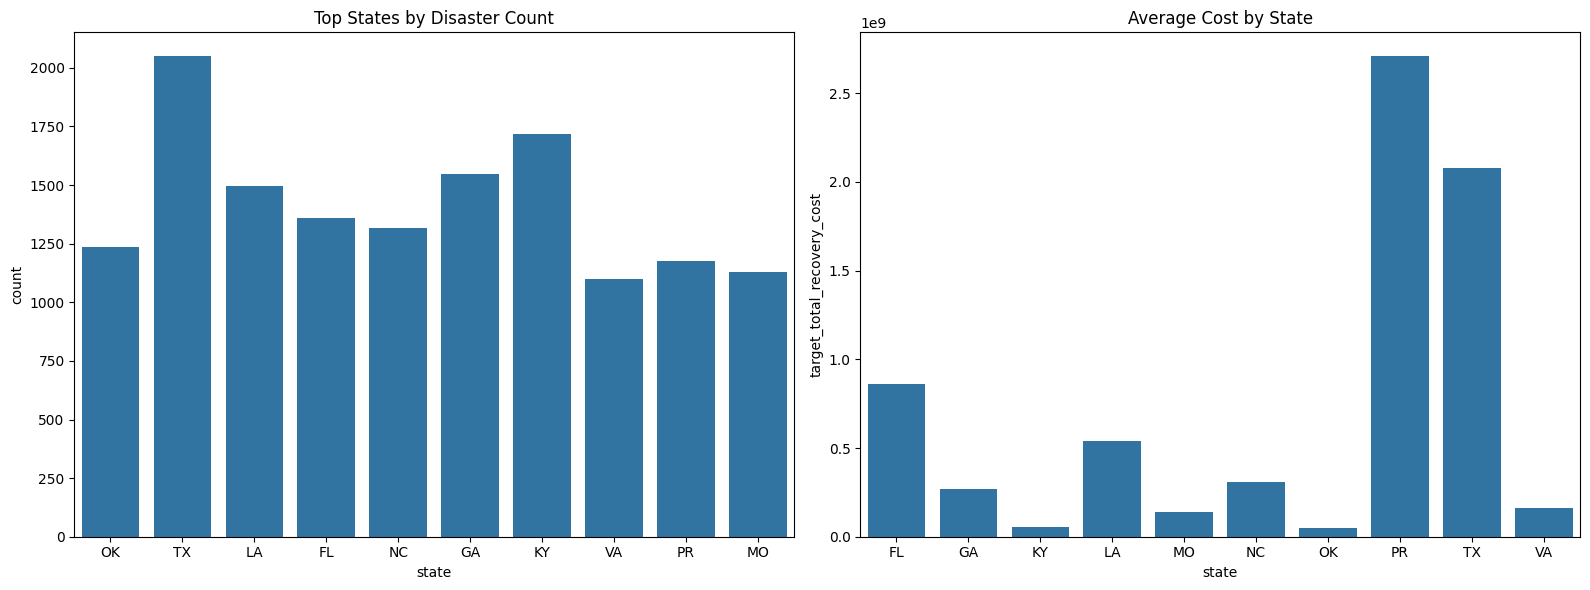

In [ ]:
# Focus on top 10 states by count and their cost distribution
top_states = disaster["state"].value_counts().head(10).index

filtered = disaster[disaster["state"].isin(top_states)]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Count
sns.countplot(data=filtered, x="state", ax=axes[0])
axes[0].set_title("Top States by Disaster Count")

# Avg cost
avg_cost = filtered.groupby("state")["target_total_recovery_cost"].mean().reset_index()
sns.barplot(data=avg_cost, x="state", y="target_total_recovery_cost", ax=axes[1])
axes[1].set_title("Average Cost by State")

plt.tight_layout()
plt.show()

Texas has the most disaster frequency while Puerto Rico has the most disaster recovery cost.

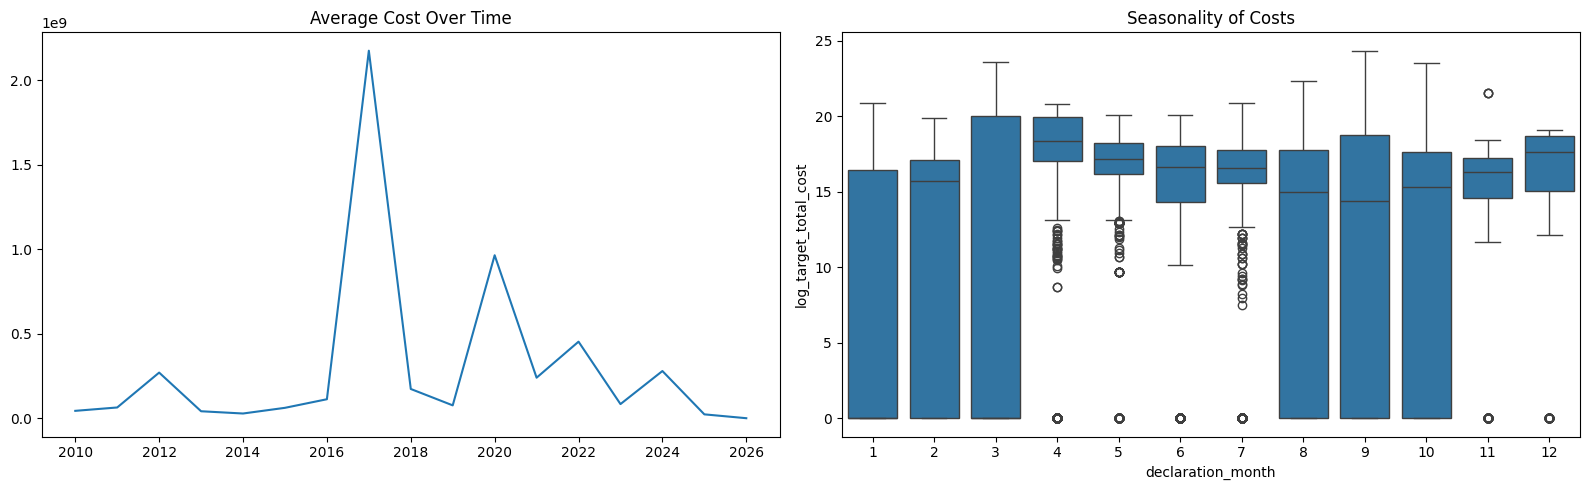

In [ ]:
# Any meaningful temporal and seasonal trends?
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Year trend
year_cost = disaster.groupby("declaration_year")["target_total_recovery_cost"].mean()
axes[0].plot(year_cost.index, year_cost.values)
axes[0].set_title("Average Cost Over Time")

# Monthly pattern
sns.boxplot(
    data=disaster,
    x="declaration_month",
    y="log_target_total_cost",
    ax=axes[1]
)
axes[1].set_title("Seasonality of Costs")

plt.tight_layout()
plt.show()

Peak average cost was 2017 (matches with reports of the "Big Three" Hurricanes to hit the USA). Costliest months so far are April - July, November and December.

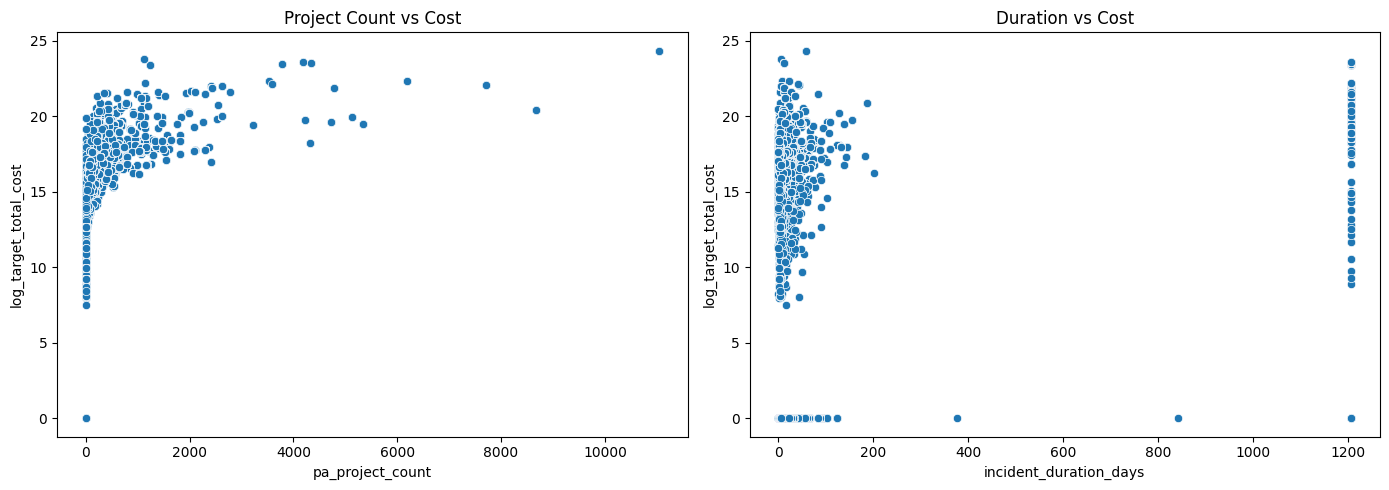

In [ ]:
# Correlation analysis (univariate)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Project count vs cost
sns.scatterplot(
    data=disaster,
    x="pa_project_count",
    y="log_target_total_cost",
    ax=axes[0]
)
axes[0].set_title("Project Count vs Cost")

# Duration vs cost
sns.scatterplot(
    data=disaster,
    x="incident_duration_days",
    y="log_target_total_cost",
    ax=axes[1]
)
axes[1].set_title("Duration vs Cost")

plt.tight_layout()
plt.show()

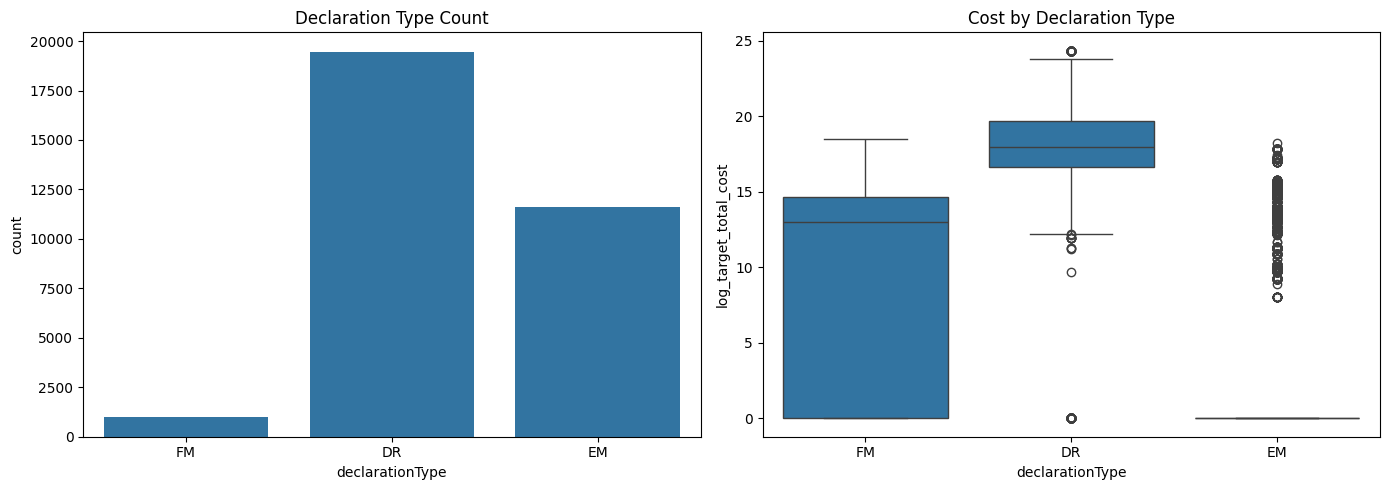

In [ ]:
# Declaration type analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=disaster, x="declarationType", ax=axes[0])
axes[0].set_title("Declaration Type Count")

sns.boxplot(
    data=disaster,
    x="declarationType",
    y="log_target_total_cost",
    ax=axes[1]
)
axes[1].set_title("Cost by Declaration Type")

plt.tight_layout()
plt.show()

Obviously storms and water-based are the most frequent. No surprise they contribute to the most expense.

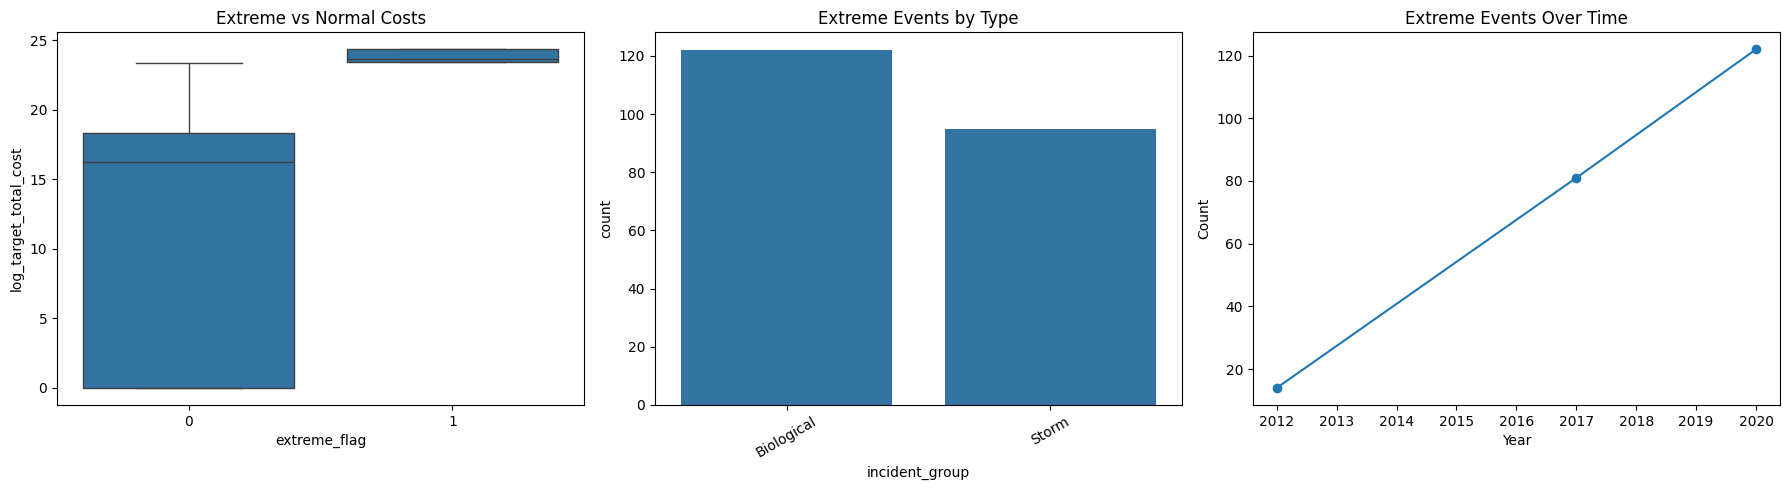

In [ ]:
# Identify extreme disaster events (top 1%)
threshold = disaster["target_total_recovery_cost"].quantile(0.99)

disaster["extreme_flag"] = (
    disaster["target_total_recovery_cost"] > threshold
).astype(int)

# Filter extreme events
extreme_df = disaster[disaster["extreme_flag"] == 1]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Distribution comparison
sns.boxplot(
    data=disaster,
    x="extreme_flag",
    y="log_target_total_cost",
    ax=axes[0]
)
axes[0].set_title("Extreme vs Normal Costs")

# Count by incident type
sns.countplot(
    data=extreme_df,
    x="incident_group",
    ax=axes[1]
)
axes[1].set_title("Extreme Events by Type")
axes[1].tick_params(axis='x', rotation=30)

# Count by year 
year_counts = extreme_df["declaration_year"].value_counts().sort_index()

axes[2].plot(year_counts.index, year_counts.values, marker='o')
axes[2].set_title("Extreme Events Over Time")
axes[2].set_xlabel("Year")
axes[2].set_ylabel("Count")

plt.tight_layout()
plt.show()

Extreme disaster events occurred in 2012, 2017 and 2020 and each one increasingly affected more states

In [24]:
disaster.head()

,disasterNumber,state,incidentType,declarationDate,incidentBeginDate,incidentEndDate,declarationType,declaration_year,declaration_month,declaration_quarter,incident_duration_days,declaration_lag_days,incident_open_flag,state_disaster_frequency,totalAmountIhpApproved,totalAmountHaApproved,totalAmountOnaApproved,totalObligatedAmountPa,totalObligatedAmountHmgp,target_pa_cost,target_total_recovery_cost,log_target_pa_cost,log_target_total_cost,pa_project_count,pa_total_obligated_sum,pa_total_obligated_mean,pa_total_obligated_median,pa_total_obligated_max,large,small,large_project_ratio,totalAmountIhpApproved_missing,totalAmountHaApproved_missing,totalAmountOnaApproved_missing,totalObligatedAmountPa_missing,totalObligatedAmountHmgp_missing,incident_group,extreme_flag
0,5529,OR,Fire,2024-08-09 00:00:00+00:00,2024-08-08 00:00:00+00:00,NaT,FM,2024,8,3,NaN,1,1,294,0.0,0.0,0.0,0.00,0.00,0.00,0.00,0.000000,0.000000,0.0,0.00,0.000000,0.000,0.00,0.0,0.0,0.000000,1,1,1,1,0,Fire,0
1,5528,OR,Fire,2024-08-06 00:00:00+00:00,2024-08-04 00:00:00+00:00,NaT,FM,2024,8,3,NaN,2,1,294,0.0,0.0,0.0,0.00,0.00,0.00,0.00,0.000000,0.000000,0.0,0.00,0.000000,0.000,0.00,0.0,0.0,0.000000,1,1,1,1,0,Fire,0
2,5527,OR,Fire,2024-08-02 00:00:00+00:00,2024-08-02 00:00:00+00:00,NaT,FM,2024,8,3,NaN,0,1,294,0.0,0.0,0.0,0.00,0.00,0.00,0.00,0.000000,0.000000,0.0,0.00,0.000000,0.000,0.00,0.0,0.0,0.000000,1,1,1,1,0,Fire,0
3,4312,CA,Severe Storm,2017-05-02 00:00:00+00:00,2017-02-08 00:00:00+00:00,2017-02-11 00:00:00+00:00,DR,2017,5,2,3.0,83,0,739,0.0,0.0,0.0,269934.77,1650.00,269934.77,271584.77,12.505939,12.512033,2.0,269934.77,134967.385000,134967.385,233307.18,1.0,1.0,0.500000,1,1,1,0,0,Storm,0
4,4251,AL,Severe Storm,2016-01-21 00:00:00+00:00,2015-12-23 00:00:00+00:00,2015-12-31 00:00:00+00:00,DR,2016,1,1,8.0,29,0,743,0.0,0.0,0.0,36201886.24,5530482.83,36201886.24,41732369.07,17.404622,17.546788,693.0,36201886.01,52239.373752,26674.610,1739135.15,51.0,642.0,0.073593,1,1,1,0,0,Storm,0
